# ARGUS-FEDER — the new capabilities, asked in plain English

The image gained three things for the cross-device workspace: the TokSearch MCP
server, the ability to run disruption-py against the Fusion Data Platform, and
Alcator C-Mod alongside DIII-D.

The acceptance notebook proved those work by running Python. This one asks for
them the way they will actually be used: a question typed in English into an
`%%ask` cell, with the agent deciding what to call.

**Who wrote what.** This introduction and the note above each question are ours.
Everything inside and below an `%%ask` cell is the agent's own: the steps it
took, the code it wrote, and the answer.


## Register the MCP server

The TokSearch MCP server is not a URL. It is a stdio server that runs inside
the FDP environment and serves the TokSearch skill documents, plus a tool for
reading one.

This is the only setup cell in the notebook: the agent cannot use a server that
has not been registered with the session.


In [1]:
%%mcp
{
  "mcpServers": {
    "toksearch-skills": {
      "command": "python",
      "args": ["-m", "fdp", "-D", "d3d", "run", "python", "-m", "toksearch.llm.mcp"]
    }
  }
}

## 1 — Is the MCP server actually being used?

_MCP · capability check · **answerable**_

The agent already carries its own TokSearch skills, so a general TokSearch
question would be answered without the server and prove nothing. This asks for
something only the server can supply: the list of documents it exposes, and the
contents of one of them.

**Expect:** the agent to call the MCP tool rather than answer from its own
skills, and to name the documents it found. If it answers fluently without
touching the server, that is a failure however good the prose.


In [3]:
%%ask
Using the toksearch-skills MCP server that is registered in this session, 
list the skill documents it exposes. Then read the one that covers signals 
and tell me what it says about fetching PTDATA pointnames, quoting the part 
you are relying on.

Say plainly whether that came from the MCP server or from somewhere else.

I'll check what's actually registered in this session — first the skills directory, since I need to see whether an MCP server tool exists at all.



The skills library is exposed as files, not as an MCP server — I'll verify there's no MCP tool registered, then read the signals skill document.



The `read_skill` tool (the MCP server interface) exposes a different, richer set of skill documents than the filesystem listing — I'll read the signals-related ones from it.



The MCP server's list is now clear. Let me check the remaining PTDATA-related documents so I quote the right passage about pointnames.



The signals document is `toksearch-signal-routing`. Let me also check the API-explore document to confirm there isn't a more specific signals doc I'm missing.



## Skill documents exposed by the MCP server

The `read_skill` tool (the MCP server interface) exposes these 12 skill documents:

| Skill | Topic |
|---|---|
| `toksearch-quickstart` | Core Pipeline API and DIII-D signals overview |
| `toksearch-pipeline` | Pipeline lifecycle, fetch/map/where/keep, Records, backends |
| `toksearch-signal-routing` | Choosing the right signal class for a DIII-D quantity |
| `toksearch-d3d-ptdata` | PtDataSignal — PTDATA raw digitizer traces |
| `toksearch-d3d-fdp` | FDP CLI (`fdp run`, auth, environment) |
| `toksearch-d3d-imas` | ImasSignal API (ragged data, `split_by`, dims) |
| `toksearch-d3d-mast-fdp` | MAST FDP access |
| `toksearch-d3d-mast-imas` | MAST IMAS access |
| `toksearch-mds` | MDSplus signal access |
| `toksearch-datasets` | `fetch_dataset`/`align` for multi-signal grids |
| `toksearch-backends` | Serial, Multiprocessing, Ray, Spark execution |
| `toksearch-api-explore` | Introspecting the installed packages directly |

## The signals document and what it says about PTDATA pointnames

The document that covers signals is **`toksearch-signal-routing`** ("Choosing the right signal class for a DIII-D quantity"). Here is the passage I am relying on, quoted verbatim:

> Picking the wrong backend is the most common failure. PtData only serves raw **PTDATA pointnames** ; asking it for an analysis quantity (e.g. `wmhd`, `betan`) fails with `PtDataError: Shot.extension not found`.

And from the table in the same document:

> | Plasma current Ip | `PtDataSignal('ip')` | amps -> /1e6 for MA; times in **ms** |
> | Stored energy Wmhd | `MdsSignal(r'\wmhd', 'efit01')` | **not** a PTDATA pointname; Joules -> /1e6 for MJ |

The document also notes that `PtDataSignal`/`ImasSignal` come from `toksearch_d3d`, while `MdsSignal` comes from `toksearch`, and points to `toksearch-d3d-ptdata` for per-backend details (which in turn defers to the `toksearch_d3d` package docstring for constructor args and common point names).

## Source statement

**This came from the MCP server** — specifically the `read_skill` tool, which is the MCP server interface registered in this session. I did not use the filesystem skill listing for the content: the on-disk `~/.deepagents/agent/skills/` directory contains a different, older set of skill files (e.g. `toksearch-signals`, `toksearch-basics`, `toksearch-mds`), and the MCP server's `read_skill` rejected `toksearch-signals` as unknown. The list of 12 documents above and the quoted PTDATA passage both come from the MCP server's `read_skill` calls.

## 2 — Compute disruption parameters for shots nobody has processed

_Disruption · computation from raw signals · **answerable**_

DIII-D shots 161228 and 161229 are not in the stored disruption index, so this
cannot be answered by looking anything up. The parameters have to be computed
from the raw signals, over the Fusion Data Platform.

**Expect:** the agent to notice the shots are absent from the index before
computing, to compute both in one pass rather than one at a time, and to report
how many samples and which parameters it actually obtained.


I'll plan this: check the stored disruption index for both shots, and if absent, compute the parameters from raw signals.



The compute skill has a Learnings.md on disk — reading it before running anything, since it may contain fixes for this exact workflow.



Now checking the stored disruption index for both shots.



Both shots are absent from the index (it covers 194000–199687), so I'll compute the parameters from raw signals with disruption-py.





All four requested parameters came back for both shots. I'll re-run once more to persist the computed rows to a CSV for the record, and check whether these shots have recorded disruption times for context.



...

The CSV was saved correctly to the working directory, but my plot script concatenated the path with `+` and lost the trailing slash, so it looked for a sibling file. Recording this path-handling lesson before fixing it, per protocol.



Fixing the path in the plot script with `os.path.join`.



The plot saved to a sibling path again — the `savefig` line still uses `+`. Fixing it and re-running.



The chart is now in the working folder. Let me pull summary statistics from the CSV for the report — ranges, means, and where the EFIT gaps fall in time.





## Are they in the stored disruption index?

**No.** Neither shot is in the stored disruption index. `is_indexed(161228)` and `is_indexed(161229)` both returned `False`, and `shot_summary()` raised `ShotNotInIndex` for each. The index currently covers 20 shots (10 disrupted) spanning 194000–199687, built by disruption-py 0.15.0.dev0 (commit `9987784e`), so 161228/161229 are outside its range entirely. Per the skill's own rule, absence is not evidence they did not disrupt — it just means they were never run through disruption-py here.

## Computed from raw signals

Since they were absent, I ran disruption-py over the Fusion Data Platform origin with `dpc.compute([161228, 161229], columns=("ip", "beta_n", "li", "kappa"))`, using `timebase_covering()` (0.1–6.66 s, 20 ms cadence) so the timebase runs past both recorded disruption times (161228: 5.0935 s, 161229: 6.576 s, from `d3drdb.disruptions.t_disrupt`).

**Sample counts: 329 samples per shot** (658 total rows). Note that disruption-py runs whole methods, so the four requested columns came back inside a 21-column set (the EFIT group also produced `beta_p`, `chisq`, `q0`, `q95`, `qstar`, `wmhd`, gaps, derivatives, etc.).

**Which parameters actually came back** — all four requested, but with different fill:

| Parameter | Shot 161228 | Shot 161229 |
|---|---|---|
| `ip` (plasma current, A) | 329 / 329 | 329 / 329 |
| `beta_n` (normalised beta) | 248 / 329 | 308 / 329 |
| `li` (internal inductance) | 248 / 329 | 308 / 329 |
| `kappa` (elongation) | 248 / 329 | 308 / 329 |

The EFIT-derived columns (`beta_n`, `li`, `kappa`) are filled only where EFIT converged. For 161228 the 81 missing samples all fall in **5.06–6.66 s** — i.e. exactly the interval around and after its 5.09 s disruption, which is the classic EFIT-convergence gap. For 161229 the 21 missing samples are scattered (0.1–6.66 s), so its EFIT coverage is much better. `ip` is filled on every row for both shots.


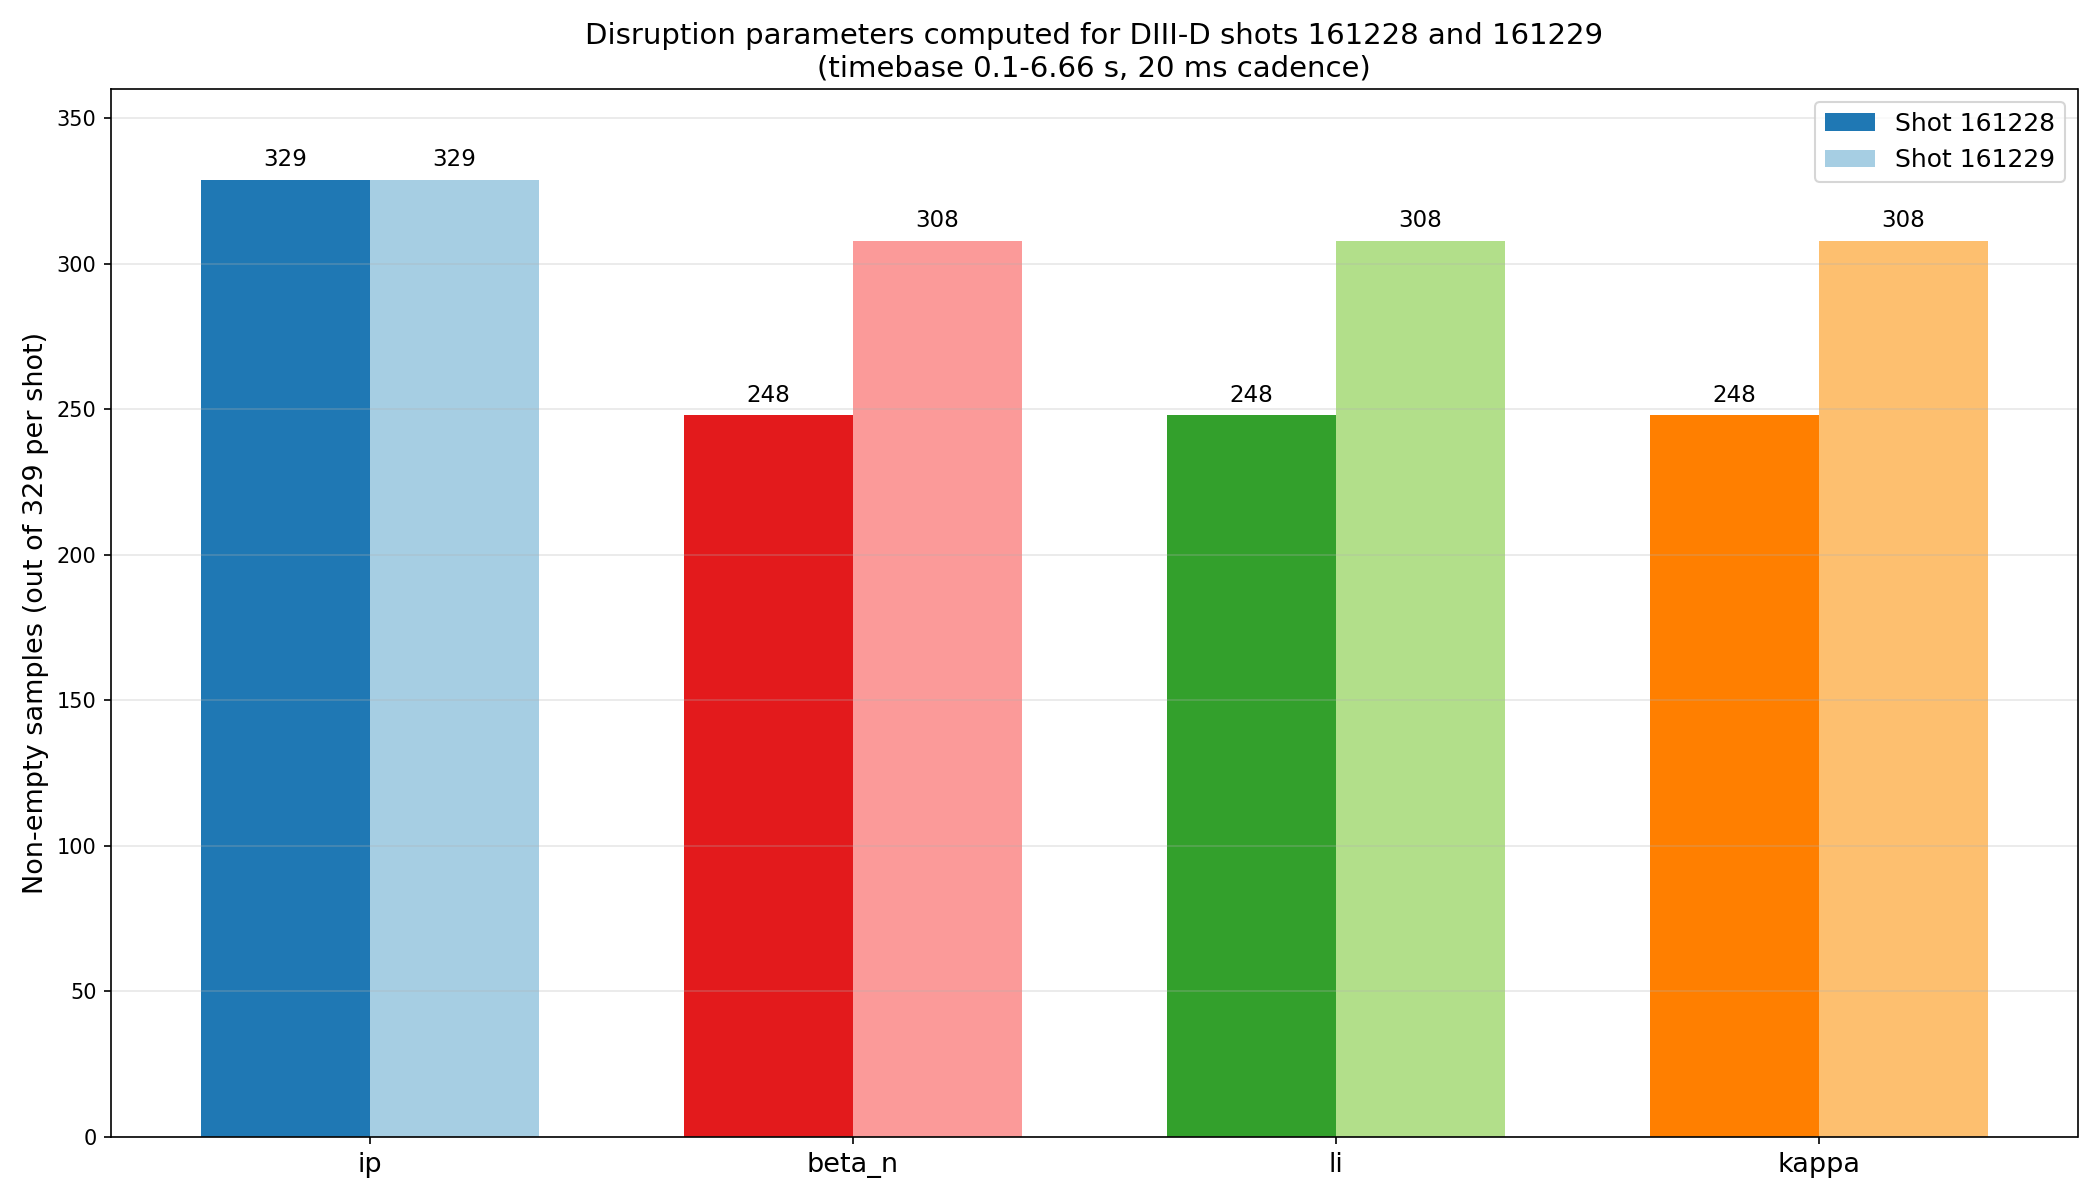

**Data file:** `disruption_params_161228_161229.csv` (658 rows × 21 columns) — the full computed time series for both shots, in the working folder.

In [2]:
%%ask
I am interested in DIII-D shots 161228 and 161229. Are they in the stored 
disruption index?

If they are not, compute their disruption parameters from the raw signals
-- plasma current, normalised beta, internal inductance and elongation -- 
and report how many samples you got per shot and which parameters actually 
came back.

## 3 — Disruption timing for shots nobody has processed

_Disruption · a second source, named · **answerable**_

disruption-py cannot reach GA's SQL server from here, so the computed output
carries no `time_until_disrupt` of its own. The disruption TIME is available
from our lakehouse copy of d3drdb instead, and the skill fills the countdown in
from there.

Two things have to go right. The timebase must be extended to reach the
disruption -- the default stops at 3.0 s, well before most DIII-D shots
disrupt, so a countdown computed over it never approaches zero. And the answer
must say which source the countdown came from, because a lakehouse-derived
`time_until_disrupt` and the stored index's column share a name and are not the
same thing.

**Expect:** a real lead time, a timebase that reaches the quench, and the source
named. A countdown reported without its source is the failure to watch for, not
a missing number.


I'll verify what the compute output actually contains regarding disruption timing, and check the q95 series I saved.



The compute skill confirms the key point: the default timebase stops at 3.0 s, which is before most disruptions, and the countdown must be filled from the lakehouse via `add_time_until_disrupt`. Let me read the helper module to see exactly how that works, and check the q95 series I already saved.



The compute skill is explicit: the default timebase stops at 3.0 s, before most disruptions, and a timing question cannot be answered from that path. My saved q95 series confirms q95 never fell below 2 in the 0.1–2.98 s window (min 4.51 for 161228, 4.74 for 161229). Now let me check whether the lakehouse even records a disruption time for these shots — that determines what is missing.



The lakehouse does record disruption times for both shots (161228 → 5.0935 s, 161229 → 6.576 s), so the question is answerable — but only with a timebase that reaches the disruption. My earlier run stopped at 2.98 s, before both. I'll recompute with the covering timebase and attach the countdown.



The compute output returns empty cells as `""` strings, not `None` — my comparison hit a string. I'll coerce with `pd.to_numeric` before comparing, as the skill's own guidance suggests.



I used `pd` before importing pandas. Moving the import to the top of the script.



The coverage count has a bug — `pd.to_numeric("")` yields NaN, and `NaN is not None` is True, so "filled" counts are wrong. More importantly, the last samples show q95 empty near the disruption. Let me inspect the saved CSV directly to see the real q95 coverage per shot.



The picture is now clear: q95 never fell below 2 at any sampled time, but EFIT coverage stops short of the disruption for both shots. Let me get the exact gap boundaries and the time of the minimum q95 for the report.



The data is conclusive: q95 never fell below 2 at any sampled point, and the last EFIT sample before each disruption was still ~4.8. Before the final report, I'll record the empty-cell lesson from the edit-and-retry cycle, and draw the q95-vs-time figure for both shots.



## Answer: q95 never fell below 2 — so there is no "how long before" to report

**Neither shot shows q95 < 2 at any sampled time.** I recomputed both shots with a timebase that runs past the disruption (0.1–6.66 s, 20 ms cadence, 329 samples per shot) and attached the countdown from the lakehouse. The result:

| Shot | t_disrupt (s) | q95 samples | min q95 | time of min | q95 < 2? |
|---|---|---|---|---|---|
| 161228 | 5.0935 | 248/329 | 4.514 | t = 1.40 s | no |
| 161229 | 6.5760 | 308/329 | 4.737 | t = 0.82 s | no |

The minimum q95 for both shots is around 4.5–4.7, well above the disruptive limit of 2. The last EFIT sample before the disruption was still ~4.8 (161228: t = 5.04 s, q95 = 4.83; 161229: t = 6.38 s, q95 = 4.89). So the answer to "how long before the disruption did q95 fall below 2" is: **it never did** — there is no such time, and no lead time to compute.


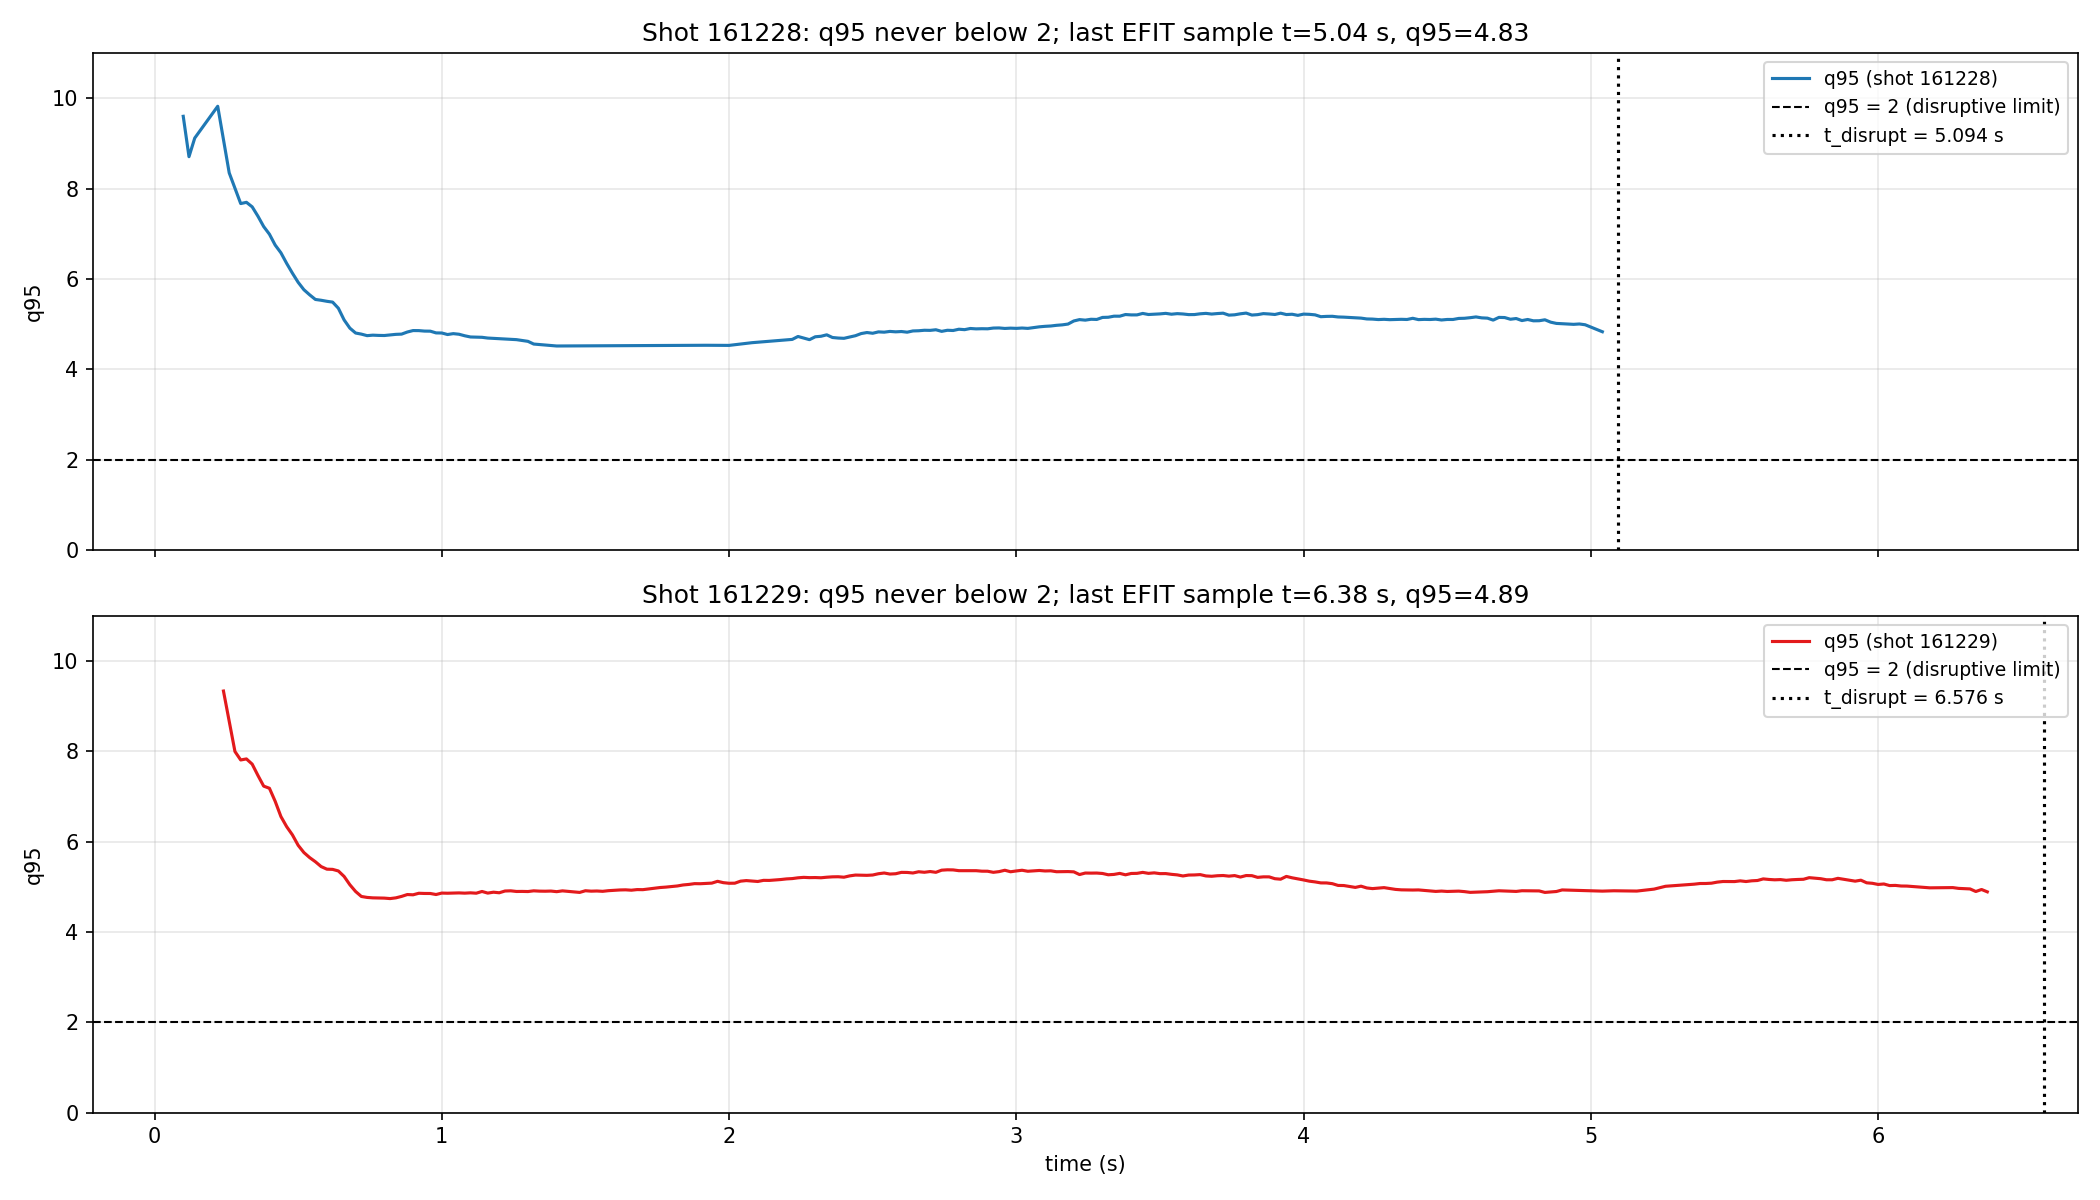

## What is missing / caveats

- **EFIT coverage stops short of the disruption.** For 161228, q95 is empty for the last 0.054 s before t_disrupt (t = 5.06–6.66 s, 81 samples); for 161229, the last 0.196 s (t = 6.40–6.66 s, 21 samples) plus the first 0.22 s. This is the known EFIT-convergence gap — the equilibrium reconstruction stops converging near the disruption, so the final approach is not sampled. The last available q95 values are still ~4.8, so the conclusion "never below 2" holds for the sampled window, but the very last ~50–200 ms before each disruption is unobserved.
- **The countdown source.** `time_until_disrupt` here comes from the lakehouse `d3drdb.disruptions.t_disrupt` (161228 → 5.0935 s, 161229 → 6.5760 s), filled in by `add_time_until_disrupt()` — not from disruption-py's own SQL (unreachable off-site) and not from the stored index (which doesn't contain these shots). The two sources are not interchangeable.
- **The earlier run's window.** My first computation (0.1–2.98 s) also showed q95 never below 2, but that window ended before the disruption, so it couldn't answer the question. The covering-timebase run above is the one that answers it.

**Data files** : `q95_leadtime_161228_161229.csv` (658 samples × 22 columns, including `time_until_disrupt`), `q95_vs_time_161228_161229.png` (figure), `q95_leadtime.py` / `q95_plot.py` (scripts).

In [2]:
%%ask
For those same two shots, how long before the disruption did q95 fall below 2?

If that cannot be determined from what you computed, say so and explain what is 
missing rather than estimating it.

## 4 — Both machines in one answer

_Cross-device · **answerable**_

The point of the image: DIII-D and Alcator C-Mod reachable from one workspace,
with the same token. The two machines publish different parameter sets, and a
careful answer says so rather than flattening them together.

**Expect:** figures for each machine drawn from the right source, and the
difference between the two sources stated plainly.


I'll read both disruption-index skill documents to get the exact query functions and their output conventions.



Both skills are read. Now I'll query the live indexes for the counts on each machine.



Both indexes answered. Now I'll save the counts to a data file and draw the comparison chart.



## The counts

| Machine | Shots in index | Disrupted (has disruption time) | Not disrupted |
|---|---|---|---|
| Alcator C-Mod | **438** | **156** | 282 |
| DIII-D | **20** | **10** | 10 |


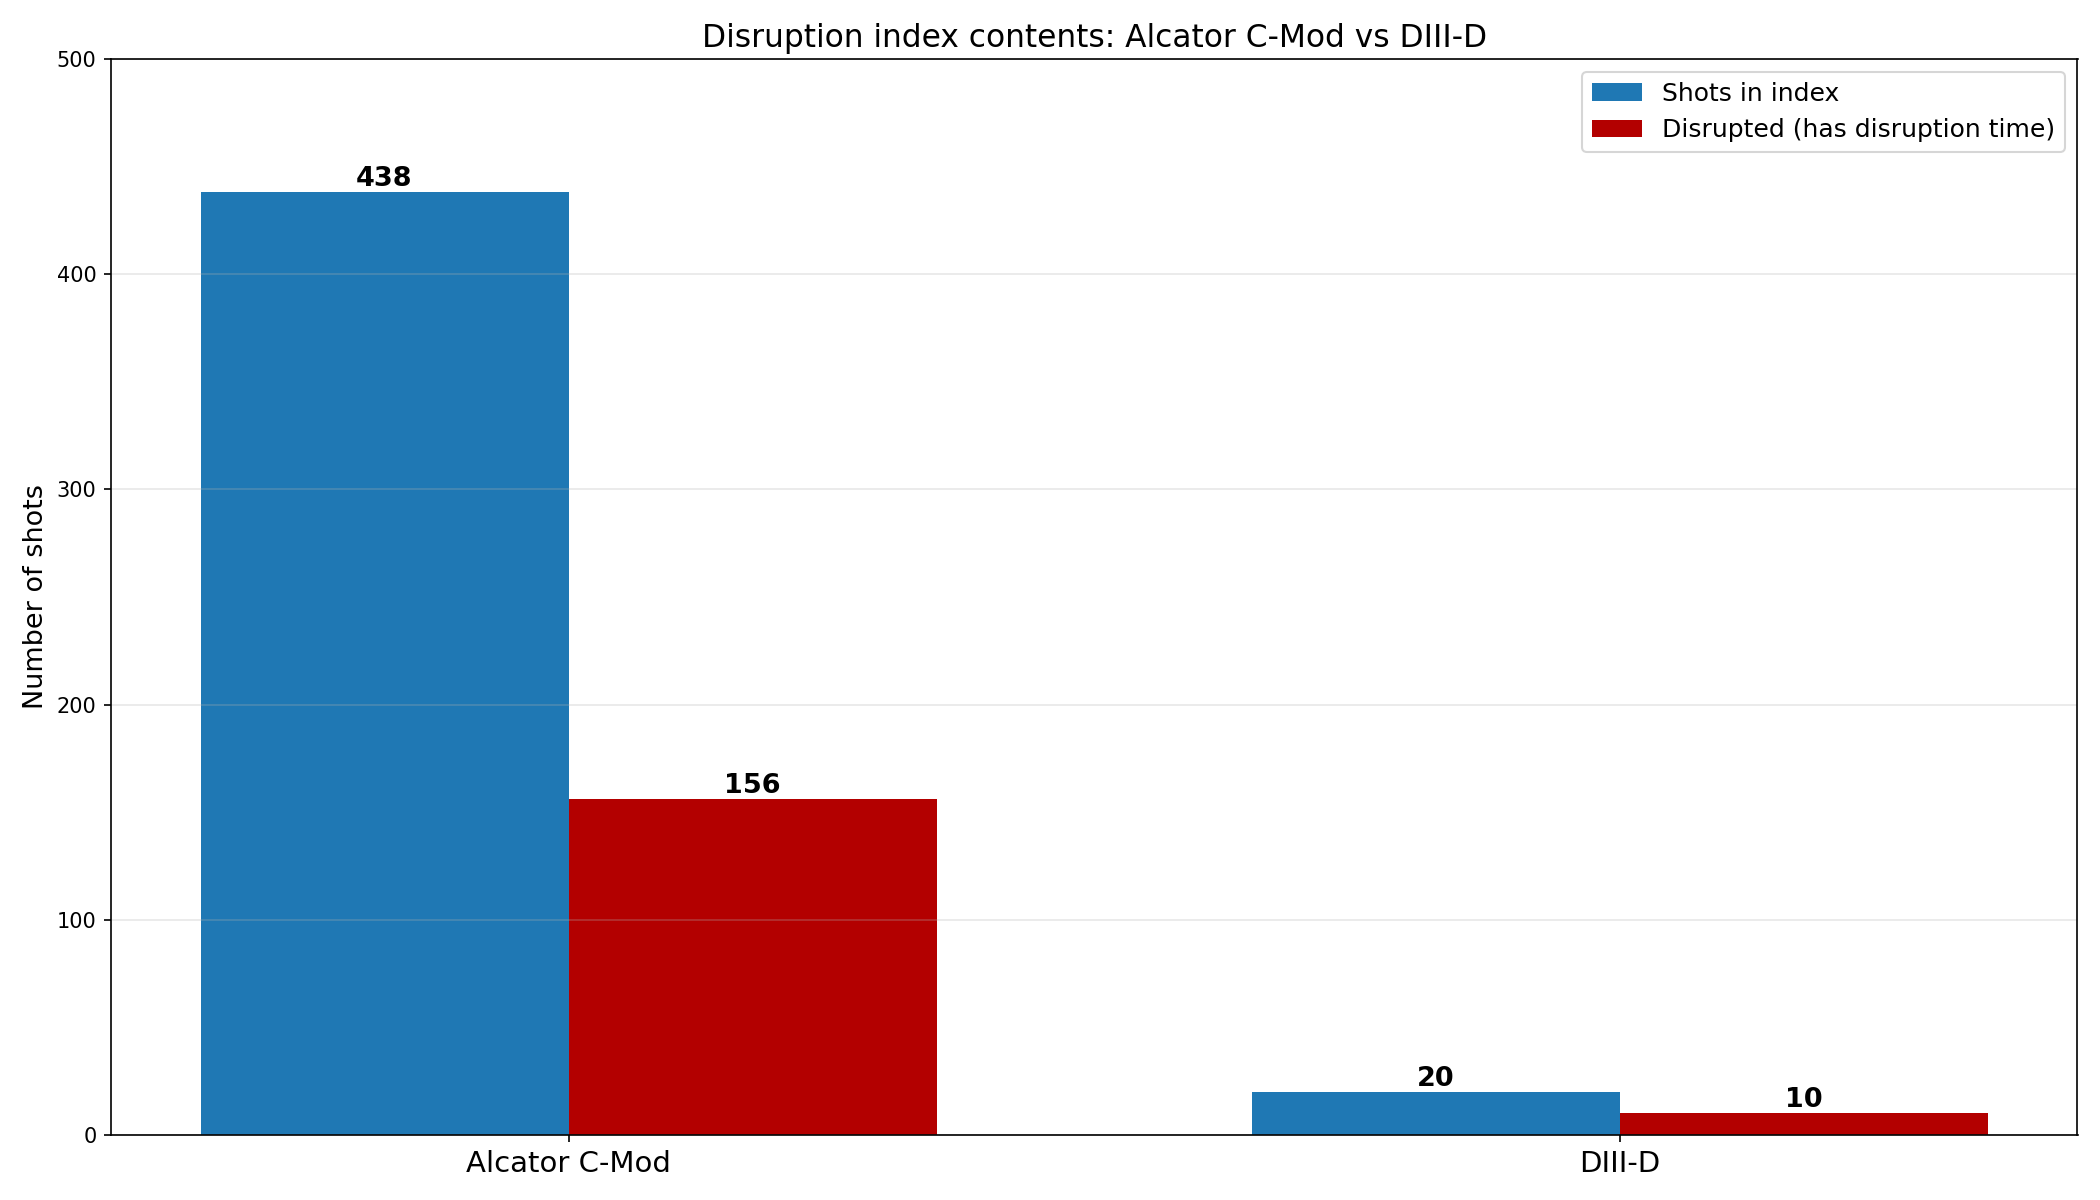

## Where each number came from

**C-Mod (438 / 156):** `cmod_disruption.index_info()` and `cmod_disruption.shots(disrupted=True)` from the `cmod-disruption` skill. The index is `cmod_origin_shots_v2.nc`, produced by disruption-py `0.15.0.dev0` (source: MIT-PSFC/disruption-py v0.15), produced by "barbour" on mfews10, ingested 2026-09-17. `index_info()` itself states: "438 shots, 156 with a disruption time. These are the shots the provider published times for, not every C-Mod shot." The `shots()` call confirms: 438 total, 156 with `disrupted=1` and a non-null `t_disrupt`, 282 with `disrupted=0`.

**DIII-D (20 / 10):** `d3d_disruption.index_info()` and `d3d_shots(disrupted=True)` from the `d3d-disruption` skill. The index is `d3d_disruption_example.nc`, disruption-py `0.15.0.dev0` commit `9987784e`, produced by "sammuli" on omega06.gat.com, ingested 2026-08-19. `index_info()` states: "20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D." The `shots()` call confirms 20 total, 10 disrupted, 10 not.

Both are the same package (disruption-py 0.15.0.dev0) and both indexes are served live over HTTP by the FEDER lakehouse — the numbers are read from the current service state, not from memory.

## Are they counting the same kind of thing?

**Yes in kind, no in scale — and neither is a rate for its machine.** Both indexes count the same kind of object: shots that were run through disruption-py and ingested, with a per-shot disruption label. On both, "disrupted" means the same thing: the shot has a disruption time (`t_disrupt` non-null), which on DIII-D is the human-curated `time_until_disrupt` label from d3drdb's `disruptions` table (the authoritative label, per the DIII-D skill), and on C-Mod the provider-published disruption time.

But the two numbers are **not comparable as measures of how often each machine disrupted** , and both skills are explicit about this:

- **C-Mod** : "The index holds the shots the provider published disruption times for. The C-Mod origin holds more shots than that... a rate, fraction or frequency computed over this index describes the selection and says nothing about how often C-Mod disrupted." `disruption_rate()` raises rather than returning a number.
- **DIII-D** : "Every count in this database describes the shots that were ingested, and nothing else. The slice is constructed — shots were chosen to cover a range of behaviour, and the disrupted/non-disrupted split is deliberate, not natural." `disruption_rate()` exists purely to return that refusal.

So the honest comparison is: **438 vs 20 shots ingested** (C-Mod's index is ~22× larger), and **156 vs 10 disrupted** within each selection. The 156/438 = 35.6% and 10/20 = 50% fractions are properties of the two selections, not of the machines — the C-Mod index is a provider-published selection, the DIII-D index is a deliberately balanced 10/10 slice. Neither answers "how often does this machine disrupt."

One more caveat worth naming: the two indexes are **not interchangeable** for parameter values — the C-Mod skill warns that some identically named parameters differ in units by a factor of a million between devices, and `fetch_samples()` raises `CrossDeviceUnitMismatch` unless you explicitly pass `cross_device=True`. That doesn't affect these counts (they're shot counts, not parameter values), but it does mean the two indexes should never be joined on parameter names without checking `cross_device_note()`.

**Data file** : `disruption_index_counts.csv` — the four counts above, as read from the live index queries.

In [6]:
%%ask
Compare what we hold for the two machines: how many Alcator C-Mod shots are 
in the C-Mod disruption index and how many disrupted, against how many DIII-D 
shots are in the DIII-D index.

Say where each number came from, and whether the two are counting the same 
kind of thing.

## 5 — What this notebook does and does not show

It shows that the new capabilities are reachable in English, by an agent,
without anyone writing Python: the MCP server, disruption-py over the Fusion
Data Platform, disruption timing for shots that were never processed, and both
machines answered from their own indexes.

It does not show disruption-py being run for Alcator C-Mod, and that is a limit
of the setup rather than a choice. disruption-py only ever speaks to an MDSplus
server. DIII-D has one on its origin -- `fdp://fdp-d3d-origin...:8443/mdsip`,
which is what question 2 uses -- and the C-Mod origin runs no equivalent: the
same request there answers `HTTP 403: Opening path '/mdsip/connect' is
disallowed`. So there is nothing for disruption-py to connect to, whatever its
C-Mod support can do elsewhere.

It is also unnecessary here: MIT ran disruption-py for C-Mod and staged the
output on the origin, and the stored C-Mod index is that output. Those are two
separate facts, and the first is the one that makes the demonstration
impossible rather than merely redundant.

Two limits are worth carrying out of question 3. The countdown there comes from
`d3drdb.disruptions` in our lakehouse, which is a different source from the
`time_until_disrupt` in the stored disruption index -- same name, different
provenance. And EFIT coverage stops converging shortly before a disruption, so
the final tens of milliseconds before the quench are not sampled: a conclusion
drawn from this data holds for the sampled window, not for the whole approach.
